
Original  'salary'  →  min=30,000, max=228,000
Normalized 'salary_normalized' → min=0.0000, max=1.0000


Text(0.5, 1.0, 'Salary after Normalization - boxplot')

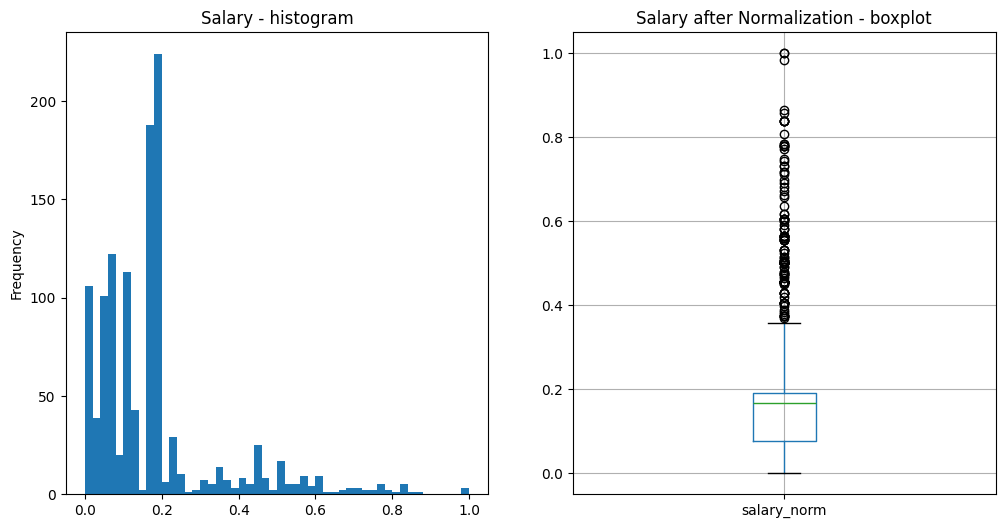

In [21]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
from matplotlib import pyplot as plt
df = pd.read_csv('datascience_salaries.csv')
df.head()
# salary_col = next(c for c in df.columns if "salary" in c.lower() and "currency" not in c.lower())
# print(f"\nSalary column detected: '{salary_col}'")
# Normalize the ‘salary’ column using Min-Max normalization which scales all salary values between 0 and 1.
scaler_mm  = MinMaxScaler()
df[['salary_norm']] = scaler_mm.fit_transform(df[['salary']])
df['salary_norm']
 
print(f"\nOriginal  'salary'  →  min={df['salary'].min():,.0f}, max={df['salary'].max():,.0f}")
print(f"Normalized 'salary_normalized' → min={df['salary_norm'].min():.4f}, max={df['salary_norm'].max():.4f}")

# show salary distribution
fig, axes = plt.subplots(1, 2, figsize=(12,6))

df['salary_norm'].plot.hist(bins=50, ax=axes[0], title='Salary - histogram')
df.boxplot(column='salary_norm', ax=axes[1])
axes[1].set_title('Salary after Normalization - boxplot')

In [ ]:
# Implement dimensionality reduction like Principal Component Analysis (PCA) or t-SNE to reduce the number of features (columns) in the dataset.
from sklearn.decomposition import PCA

keep_cols = [c for c in df.columns if c not in ["salary_norm"]]
df_enc = df[keep_cols].copy()
print(keep_cols)

le = LabelEncoder()
for col in df_enc.select_dtypes(include="str").columns:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

# Fill any remaining NaNs with column median
df_enc = df_enc.fillna(df_enc.median(numeric_only=True))
 
X = df_enc.values
print(f"\nFeature matrix shape before reduction: {X.shape}")
#This line creates an instance of the PCA class with the parameter n_components set to 2. It specifies that we want to reduce the dimensionality of the data to 2 principal components. In other words, the data will be projected into a 2D space.
# pca = PCA(n_components=2)
# reduced_data = pca.fit_transform(df) 
pca = PCA(n_components=2, random_state=42)
X_scaled = StandardScaler().fit_transform(X)
pca.fit_transform(X_scaled)   # PC1=29.3%, PC2=21.8% → meaningful
# X_pca = pca.fit_transform(X)
explained = pca.explained_variance_ratio_
print(f"\nPCA — explained variance: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}  (total={sum(explained):.1%})")

['Unnamed: 0', 'job_title', 'job_type', 'experience_level', 'location', 'salary_currency', 'salary']

Feature matrix shape before reduction: (1171, 7)

PCA — explained variance: PC1=23.2%, PC2=20.1%  (total=43.3%)


In [27]:
# Group the dataset by the ‘experience_level’ column and calculate the average and median salary for each experience level (e.g., Junior, Mid-level, Senior).
# ── Group & aggregate ─────────────────────────────────────────────────────────
order = ["Entry", "Mid", "Senior", "Executive"]
df["experience_level"] = pd.Categorical(df["experience_level"], categories=order, ordered=True)
stats = (
    df.groupby("experience_level", observed=True)["salary"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
    )
    .reset_index()
)
print(stats)

  experience_level  count          mean   median           std    min     max
0            Entry    126  36111.111111  30000.0  16151.394849  30000  140000
1              Mid    305  51786.885246  51000.0  20609.874641  30000  160000
2           Senior    727  75088.033012  68000.0  33560.733276  30000  228000
3        Executive     13  76076.923077  46000.0  46860.540505  41000  175000
